# Stefan-Boltzmann Experiment
### Radiated power versus filament temperature

A tungsten lamp is driven at increasing currents. Its resistance gives the filament temperature, while a thermopile measures the emitted radiation. Fitting `log(U_thermopile)` against `log(T)` recovers the Stefan-Boltzmann exponent, expected to be 4.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # make the physexp package importable
from physexp import stefan_boltzmann as sb, plots
from physexp.display import uframe, apply_style
apply_style()

## 1. Raw measurements

Current, lamp voltage and thermopile voltage from `data/stefan_boltzmann.csv`.

In [2]:
raw = sb.load_measurements()
raw

,step,current_A,lamp_voltage_V,thermopile_voltage_V
0,0,2.00,0.98,0.017
1,1,2.25,1.36,0.054
2,2,2.50,1.76,0.108
3,3,2.75,2.15,0.180
4,4,3.00,2.56,0.276
5,5,3.25,3.02,0.390
6,6,3.50,3.49,0.534
7,7,3.75,3.99,0.692
8,8,4.00,4.55,0.897
9,9,4.25,5.08,1.113


## 2. Derived quantities

Resistance, temperature and the log-log pair used in the fit.

In [3]:
result = sb.run()
print('Nominal resistance  R_0 = {:.2u} ohm'.format(result.nominal_resistance))
uframe(
    {
        'resistance_ohm': result.table['resistance_ohm'],
        'temperature_K': result.table['temperature_K'],
        'log_T': result.table['log_T'],
        'log_U_term': result.table['log_U_term'],
    },
    current_A=result.table['current_A'],
)

Nominal resistance  R_0 = 0.15886+/-0.00081 ohm


,resistance_ohm,temperature_K,log_T,log_U_term,current_A
0,0.4900+/-0.0056,682.0+/-7.1,6.525+/-0.010,-4.07+/-0.59,2.00
1,0.6044+/-0.0052,813.9+/-6.8,6.7018+/-0.0084,-2.92+/-0.19,2.25
2,0.7040+/-0.0049,925.3+/-6.7,6.8301+/-0.0072,-2.226+/-0.093,2.50
3,0.7818+/-0.0046,1010.3+/-6.6,6.9180+/-0.0065,-1.715+/-0.056,2.75
4,0.8533+/-0.0044,1087.0+/-6.6,6.9912+/-0.0060,-1.287+/-0.036,3.00
5,0.9292+/-0.0042,1167.0+/-6.6,7.0622+/-0.0057,-0.942+/-0.026,3.25
6,0.9971+/-0.0040,1237.3+/-6.7,7.1207+/-0.0054,-0.627+/-0.019,3.50
7,1.0640+/-0.0039,1305.6+/-6.7,7.1744+/-0.0052,-0.368+/-0.014,3.75
8,1.1375+/-0.0038,1379.4+/-6.9,7.2294+/-0.0050,-0.109+/-0.011,4.00
9,1.1953+/-0.0037,1436.6+/-7.0,7.2701+/-0.0049,0.1071+/-0.0090,4.25


## 3. Stefan-Boltzmann exponent

Uncertainty-weighted linear fit of the log-log data.

In [4]:
print('Fitted exponent  n = {:.2u}   (expected 4)'.format(result.exponent))
print('Fit intercept      = {:.2u}'.format(result.intercept))

Fitted exponent  n = 4.923+/-0.056   (expected 4)
Fit intercept      = -35.70+/-0.40


### Sensitivity to the fitting method

The original coursework never fit this exponent, so there is no reference value to check it against. The log-log **inputs** match the original digit for digit, but the exponent itself depends on how the errors are treated: it ranges from about 4.9 to 5.5 across standard methods. That method-choice spread (~0.5) dwarfs the ±0.06 statistical uncertainty of any single fit, so the quoted uncertainty alone overstates how well the exponent is known.

In [5]:
result.exponent_methods

,method,exponent
0,weighted (y errors) - primary,4.922561
1,ordinary least squares,5.480465
2,orthogonal distance (x and y errors),5.048210


## 4. Figure

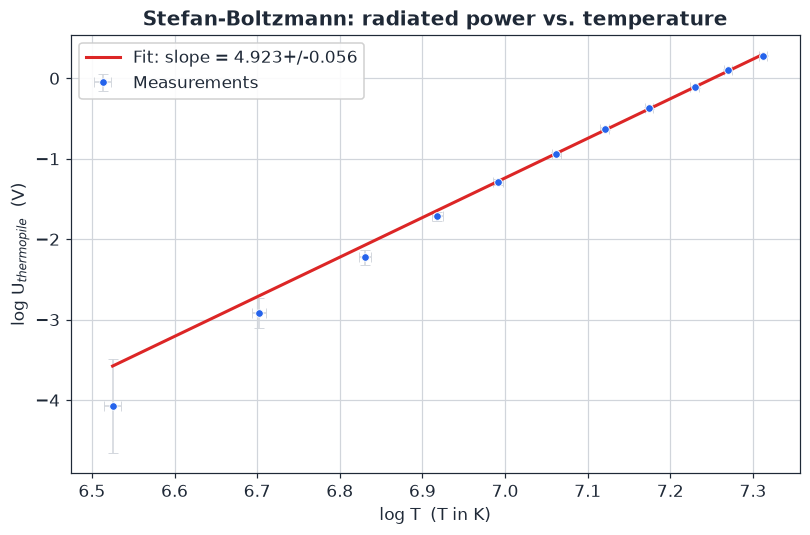

In [6]:
plots.stefan_boltzmann_fit(result);